# Lecture 5b — Features and labels: the two ends nobody teaches

**AI-powered Investment and Risk Management**

Almost all the attention in machine learning for trading goes to the model. Almost all the damage happens on either side of it: in how the features were built, and in how the target was defined.

This notebook works on both ends. We will build eighty-six technical indicators and find out how many distinct ideas they contain, watch a single default argument fabricate data, buy stationarity without destroying memory, and then discover that the label — not the model — decides whether a profitable strategy was ever possible.

**What you will be able to do afterwards**

- Build a technical feature matrix without silently inventing values
- Measure how much independent information a large indicator set actually holds
- Choose a differencing parameter that trades stationarity against memory, rather than defaulting to returns
- Compute the directional accuracy a strategy needs before it breaks even
- Build fixed-horizon, triple-barrier and meta-labels, and say what each can and cannot express

**Runtime** — about 90 seconds. `Lec05a` is assumed but not required.

---

In [46]:
# Colab: uncomment.
# !pip install -q ta TA-Lib plotly ipywidgets

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from statsmodels.tsa.stattools import adfuller

import ta
import airm5 as a
from airm5 import C, style

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

try:
    import ipywidgets as W
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

try:
    import talib
    HAS_TALIB = True
except ImportError:
    HAS_TALIB = False

print(f"ta {'ok':>4} | TA-Lib {'ok' if HAS_TALIB else 'not installed'} | "
      f"widgets {'ok' if HAS_WIDGETS else 'no'}")

ta   ok | TA-Lib ok | widgets ok


## 1. One default argument, and what it does

We will work with Apple's daily bars, five years of them. The `ta` library will build eighty-six indicators from those five columns with a single call.

That call takes a `fillna` argument. Almost every tutorial sets it to `True`, because otherwise the top of the frame is full of `NaN` and things break downstream. Let us look at what setting it to `True` actually does.

In [29]:
ohlcv = a.load_ohlcv("AAPL")
print(f"AAPL: {len(ohlcv):,} daily bars, "
      f"{ohlcv.index[0].date()} to {ohlcv.index[-1].date()}\n")

raw_clean  = ta.add_all_ta_features(ohlcv.copy(), "Open", "High", "Low",
                                    "Close", "Volume", fillna=False)
raw_filled = ta.add_all_ta_features(ohlcv.copy(), "Open", "High", "Low",
                                    "Close", "Volume", fillna=True)
clean  = raw_clean.drop(columns=list(ohlcv.columns)).replace([np.inf, -np.inf], np.nan)
filled = raw_filled.drop(columns=list(ohlcv.columns))

n_missing = int(clean.isna().sum().sum())
print(f"Indicators built                      : {clean.shape[1]}")
print(f"Cells genuinely unknown (fillna=False): {n_missing:,} "
      f"({n_missing/clean.size:.1%} of the matrix)")
print(f"Features containing at least one      : {int((clean.isna().sum()>0).sum())}")
print(f"Cells still unknown after fillna=True : {int(filled.isna().sum().sum())}")

AAPL: 1,259 daily bars, 2013-02-08 to 2018-02-07



Task was destroyed but it is pending!
task: <Task pending name='Task-614' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-615' coro=<Kernel.shell_main() running at C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-615' coro=<Kernel.shell_main() running at C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Indicators built                      : 86
Cells genuinely unknown (fillna=False): 2,594 (2.4% of the matrix)
Features containing at least one      : 67
Cells still unknown after fillna=True : 0


Two and a half thousand values that the data cannot support become numbers, and the evidence that they were ever missing is gone. Where do the replacements come from? Three different places, and they are not equally bad.

In [30]:
missing_rate = clean.isna().mean().sort_values(ascending=False)
print("Most-missing indicators:\n")
print((missing_rate.head(6) * 100).round(1).astype(str).add(" %").to_string())

structural = missing_rate[missing_rate > 0.2]
print(f"\nMissing more than 20% of the time: {list(structural.index)}")
print("\nThese two are not incomplete. The parabolic SAR sits either above or")
print("below the price, never both, so exactly one of the pair is undefined on")
print("any given day. That is the indicator working correctly.")

Most-missing indicators:

trend_psar_down     58.1 %
trend_psar_up       42.1 %
trend_stc            5.6 %
trend_trix           3.4 %
trend_mass_index     3.2 %
momentum_tsi         2.9 %

Missing more than 20% of the time: ['trend_psar_down', 'trend_psar_up']

These two are not incomplete. The parabolic SAR sits either above or
below the price, never both, so exactly one of the pair is undefined on
any given day. That is the indicator working correctly.


In [31]:
# Backfill audit: does any feature's leading block hold a value from the future?
leaks = {}
for col in clean.columns:
    fv = clean[col].first_valid_index()
    if fv is None:
        continue
    k = clean.index.get_loc(fv)
    if k == 0:
        continue
    if np.isclose(filled[col].iloc[:k], clean[col].loc[fv], rtol=1e-9).all():
        leaks[col] = k

print("LOOK-AHEAD (values copied backwards from the future)")
print(f"  features affected : {len(leaks)} of {clean.shape[1]}")
for k_, v_ in sorted(leaks.items(), key=lambda kv: -kv[1]):
    print(f"    {k_:<20s} first {v_} rows hold the value from row {v_}")

warmup = clean.drop(columns=structural.index)
print(f"\nFABRICATION (values invented where nothing was knowable)")
print(f"  structurally undefined cells replaced : "
      f"{int(clean[structural.index].isna().sum().sum()):,}")
print(f"  warm-up cells replaced                : "
      f"{int(warmup.isna().sum().sum()):,}")
print(f"  longest warm-up                       : "
      f"{int(warmup.isna().sum().max())} rows ({warmup.isna().sum().idxmax()})")

LOOK-AHEAD (values copied backwards from the future)
  features affected : 2 of 86
    trend_psar_up        first 19 rows hold the value from row 19
    trend_psar_down      first 2 rows hold the value from row 2

FABRICATION (values invented where nothing was knowable)
  structurally undefined cells replaced : 1,261
  warm-up cells replaced                : 1,333
  longest warm-up                       : 71 rows (trend_stc)


Here is the honest accounting, and it is worth being precise because the convenient story is not quite the true one.

**The look-ahead is real but small.** Two indicators out of eighty-six have leading rows filled backwards from the future, affecting at most nineteen rows of a 1,259-row series. If you were expecting the headline sin of Lecture 2, this is not it.

**The fabrication is large.** More than a thousand cells belonging to the parabolic SAR pair are not missing data at all — they are *undefined*, and `fillna=True` replaces them with zero. A model reading `trend_psar_up = 0` will treat that as a price level of zero dollars sitting next to a price level of $150. It is not a gap being patched. It is a reading being manufactured.

**And the real problem is neither.** It is that after `fillna=True` the frame looks complete. Nothing warns you. The indicator column that is undefined 58% of the time looks exactly like the one that is always valid, and the row where your slowest indicator has not warmed up looks exactly like the row a year later. You cannot audit what you cannot see.

The alternative is not difficult. Drop the structurally-undefined columns, drop the warm-up rows, and accept the cost in sample size.

In [32]:
features = a.ta_features(ohlcv, report=True)

86 indicators built
  dropped as structurally missing : ['trend_psar_up', 'trend_psar_down']
  rows dropped as warm-up         : 71
  usable feature matrix           : (1188, 84)


Seventy-one rows out of 1,259 — under 6% of the sample — to remove every fabricated value in the matrix. That is the whole price of doing it properly.

<details>
<summary><b>Why zero is the worst possible filler</b></summary>

A tree-based model splits on thresholds. Filling an undefined parabolic SAR with zero places every one of those observations in the extreme left tail of that feature's distribution, far below any genuine value. The model will happily discover that "`trend_psar_up` below $1" predicts something — because that condition is not a price level at all, it is a proxy for "the SAR was on the other side", which is itself a trend signal. The feature has become a disguised copy of a different feature, and no feature-importance measure will tell you.

Median or mean imputation is less catastrophic but still asserts a value where none exists. For a warm-up period the correct answer is that the observation is unusable.
</details>

## 2. Eighty-six indicators, how many ideas?

Now the substantive question. The library gives eighty-six features. Does it give eighty-six pieces of information?

In [33]:
def redundancy_profile(name, careless):
    """careless=True reproduces the usual recipe: fillna=True, keep everything."""
    o = a.load_ohlcv(name)
    if careless:
        F = ta.add_all_ta_features(o.copy(), "Open", "High", "Low", "Close",
                                   "Volume", fillna=True).drop(columns=list(o.columns))
        F = F.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    else:
        F = a.ta_features(o)
    F = F.loc[:, F.std() > 0]
    kept, _ = a.drop_correlated(F, 0.9)
    Z = (F - F.mean()) / F.std()
    ev = np.linalg.eigvalsh(np.cov(Z.values.T))[::-1]
    ev = ev / ev.sum()
    return {"Stock": name, "Features": F.shape[1], "Survive |ρ| < 0.9": kept.shape[1],
            "PCs for 90% of variance": int(np.searchsorted(np.cumsum(ev), 0.90) + 1),
            "PC1 share": f"{ev[0]:.1%}"}

stocks = ["AAPL", "JPM", "XOM", "KO", "NVDA"]
print("The usual recipe — fillna=True, keep every column:\n")
print(pd.DataFrame([redundancy_profile(n, careless=True) for n in stocks])
      .to_string(index=False))
print("\nDone properly — structurally undefined columns and warm-up rows removed:\n")
rows = [redundancy_profile(n, careless=False) for n in stocks]
redundancy = pd.DataFrame(rows)
print(redundancy.to_string(index=False))

The usual recipe — fillna=True, keep every column:

Stock  Features  Survive |ρ| < 0.9  PCs for 90% of variance PC1 share
 AAPL        86                 48                       14     33.0%
  JPM        86                 47                       14     35.8%
  XOM        86                 45                       14     30.0%
   KO        86                 45                       14     31.3%
 NVDA        86                 46                       14     38.0%

Done properly — structurally undefined columns and warm-up rows removed:

Stock  Features  Survive |ρ| < 0.9  PCs for 90% of variance PC1 share
 AAPL        84                 43                       13     31.3%
  JPM        84                 44                       13     35.7%
  XOM        84                 42                       13     30.9%
   KO        84                 42                       13     32.2%
 NVDA        84                 43                       13     37.9%


Look at the two tables together, because the comparison answers a question you should be asking by now: *does cleaning the data change the conclusion?*

The careless recipe reports 86 features, about 48 survivors and **fourteen** components for 90% of the variance. The careful one reports 84 features, about 43 survivors and **thirteen**. The numbers move a little; the finding does not move at all.

And the finding is worth stating precisely. The component count is identical on every one of the five stocks — across a technology company, a bank, an oil major, a consumer staple and a semiconductor manufacturer. Not approximately equal, not equal on average. Identical. The first component alone carries about a third.

Eighty-odd columns. Roughly a dozen ideas.

In [34]:
F = a.ta_features(ohlcv)
F = F.loc[:, F.std() > 0]
Zc = ((F - F.mean()) / F.std())
corr = Zc.corr()

In [35]:
corr

,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,volume_vpt,volume_vwap,volume_mfi,volume_nvi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
volume_adi,1.000,0.499,0.369,0.076,0.037,0.193,0.426,0.889,0.108,0.776,...,0.197,0.208,0.009,0.060,0.054,0.033,0.891,0.021,0.022,0.898
volume_obv,0.499,1.000,0.189,0.093,0.030,0.141,0.940,0.729,0.228,0.437,...,0.259,0.269,0.024,0.052,0.058,0.012,0.738,0.038,0.039,0.742
volume_cmf,0.369,0.189,1.000,0.401,0.133,0.428,0.128,0.196,0.517,0.219,...,0.525,0.431,0.388,-0.135,-0.155,-0.028,0.212,0.151,0.153,0.241
volume_fi,0.076,0.093,0.401,1.000,0.311,0.514,0.130,-0.065,0.580,-0.095,...,0.607,0.411,0.701,-0.149,-0.145,-0.067,-0.047,0.450,0.453,0.020
volume_em,0.037,0.030,0.133,0.311,1.000,0.281,0.018,-0.010,0.151,0.011,...,0.048,-0.014,0.192,-0.090,-0.065,-0.071,-0.005,0.563,0.564,0.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum_pvo_hist,0.033,0.012,-0.028,-0.067,-0.071,-0.030,0.017,0.046,-0.058,0.017,...,-0.003,0.033,-0.106,0.642,0.112,1.000,0.037,-0.004,-0.010,0.034
momentum_kama,0.891,0.738,0.212,-0.047,-0.005,0.121,0.677,0.999,0.025,0.821,...,0.087,0.115,-0.064,0.107,0.112,0.037,1.000,-0.033,-0.033,0.996
others_dr,0.021,0.038,0.151,0.450,0.563,0.145,0.032,-0.037,0.152,-0.020,...,0.056,-0.007,0.198,-0.018,-0.021,-0.004,-0.033,1.000,1.000,0.011
others_dlr,0.022,0.039,0.153,0.453,0.564,0.147,0.033,-0.036,0.155,-0.020,...,0.059,-0.005,0.199,-0.024,-0.024,-0.010,-0.033,1.000,1.000,0.012


In [36]:
def plot_correlation_heatmap(df, figsize=(12, 10), mask_upper=True, tick_fontsize=8):
    """
    Create an improved correlation heatmap with better visibility.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame
    figsize : tuple
        Figure size (width, height)
    mask_upper : bool
        If True, mask the upper triangle of the heatmap
    tick_fontsize : int
        Font size for tick labels on both axes
    """
    # Compute correlation matrix
    corr_matrix = df.corr()
    
    # Create mask for upper triangle
    mask = None
    if mask_upper:
        mask = np.triu(np.ones_like(corr_matrix), k=0)
    
    # Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    # Draw the heatmap
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=False,                # Show numbers
                fmt='.2f',                  # Format numbers to 2 decimal places
                cmap=cmap,
                center=0,                   # Center colormap at 0
                square=True,                # Force square shape
                linewidths=0.5,             # Add grid lines
                cbar_kws={'shrink': .5},    # Adjust colorbar size
                annot_kws={'size': 8},      # Adjust font size of numbers
                xticklabels=corr_matrix.columns,
                yticklabels=corr_matrix.columns,
                ax=ax)
    
    # Adjust tick label sizes
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    
    # Rotate x-axis labels
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout and title
    plt.title('Correlation Matrix Heatmap', pad=20)
    plt.tight_layout()
    
    return

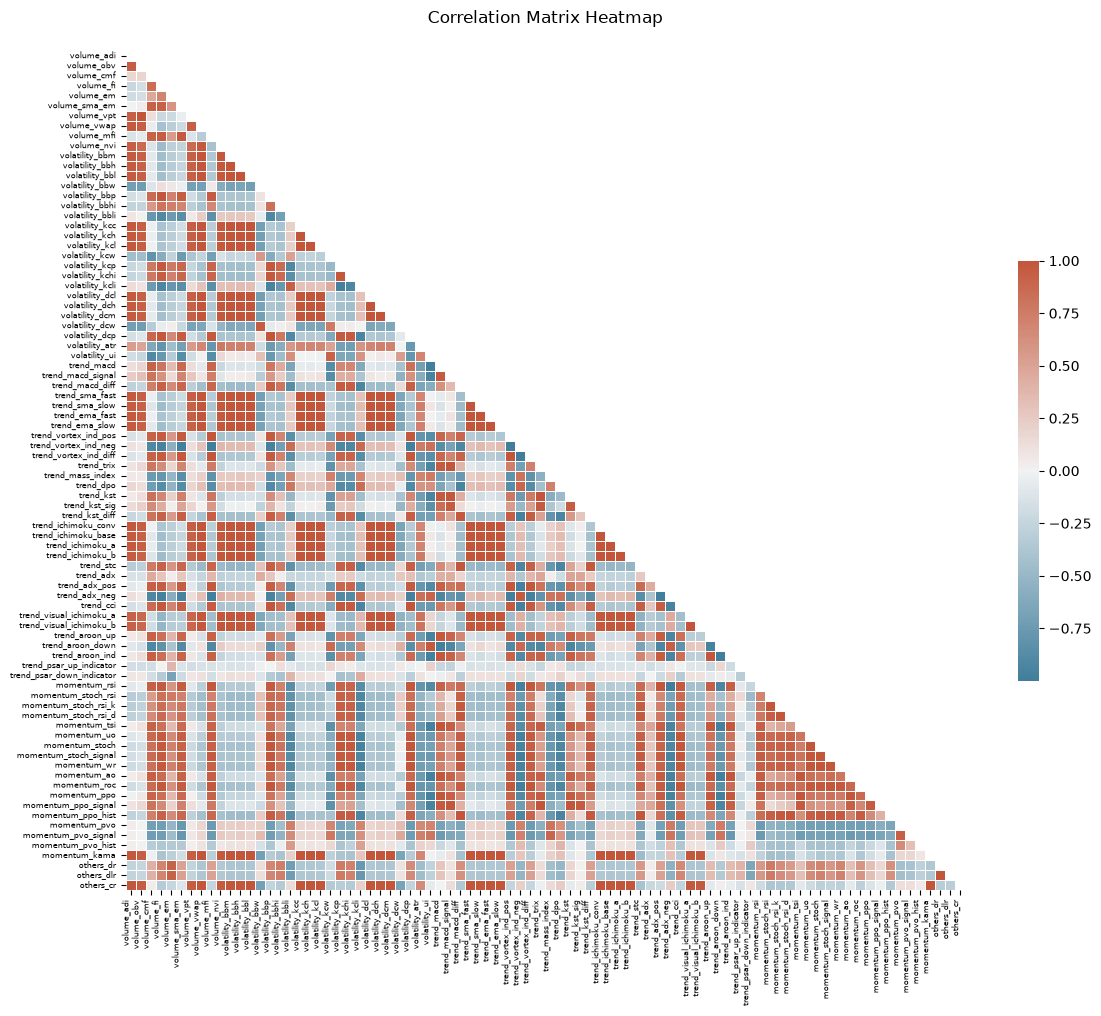

In [42]:
plot_correlation_heatmap(corr, tick_fontsize=6)

The function below is a slight modification, allowing your to group items in the correlation matrix:

In [43]:
# Alternative version with feature clustering
def plot_clustered_correlations(df, figsize=(12, 10), tick_fontsize=8, mask_upper=True):
    """
    Create a correlation heatmap with clustered features.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame
    figsize : tuple
        Figure size (width, height)
    tick_fontsize : int
        Font size for tick labels on both axes
    mask_upper : bool
        If True, mask the upper triangle of the heatmap
    """
    # Compute correlation matrix
    corr_matrix = df.corr()
    
    # Convert correlations to distances
    dissimilarity = 1 - abs(corr_matrix)
    
    # Perform hierarchical clustering
    links = scipy.cluster.hierarchy.linkage(dissimilarity, method='complete')
    order = scipy.cluster.hierarchy.dendrogram(links, no_plot=True)['leaves']
    
    # Reorder correlation matrix
    corr_matrix = corr_matrix.iloc[order, order]
    
    # Create mask for upper triangle if requested
    mask = None
    if mask_upper:
        mask = np.triu(np.ones_like(corr_matrix), k=0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    # Create heatmap with clustered features
    sns.heatmap(corr_matrix,
                mask=mask,
                annot=False,
                fmt='.2f',
                cmap=cmap,
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={'shrink': .5},
                annot_kws={'size': tick_fontsize},
                xticklabels=corr_matrix.columns,
                yticklabels=corr_matrix.columns,
                ax=ax)
    
    # Adjust tick label sizes
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    
    # Rotate labels
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout and title
    plt.title('Clustered Correlation Matrix Heatmap', pad=20)
    plt.tight_layout()
    
    return

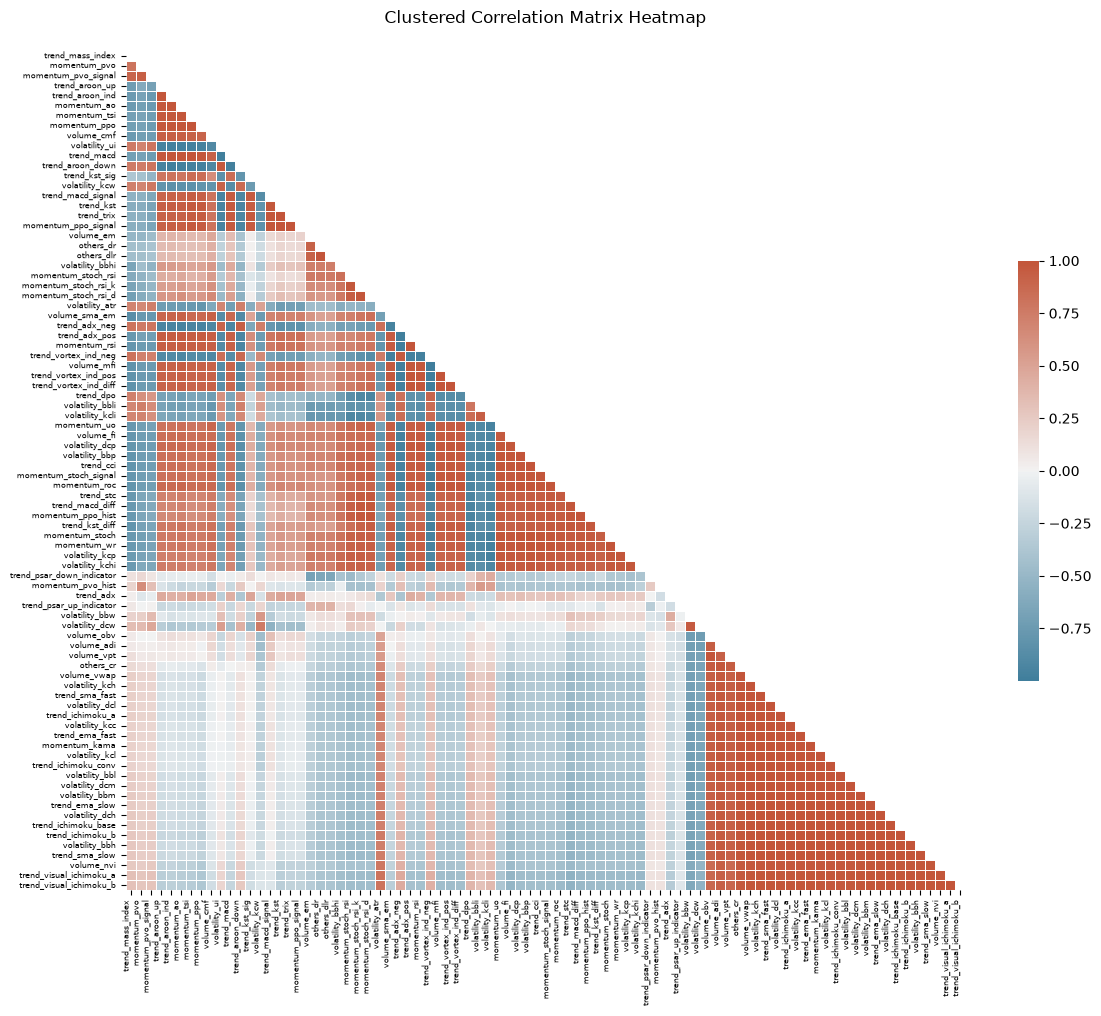

In [47]:
plot_clustered_correlations(corr, tick_fontsize=6, mask_upper=True)

The function below is a interactive Plotly, effectivly plotting the same thing:

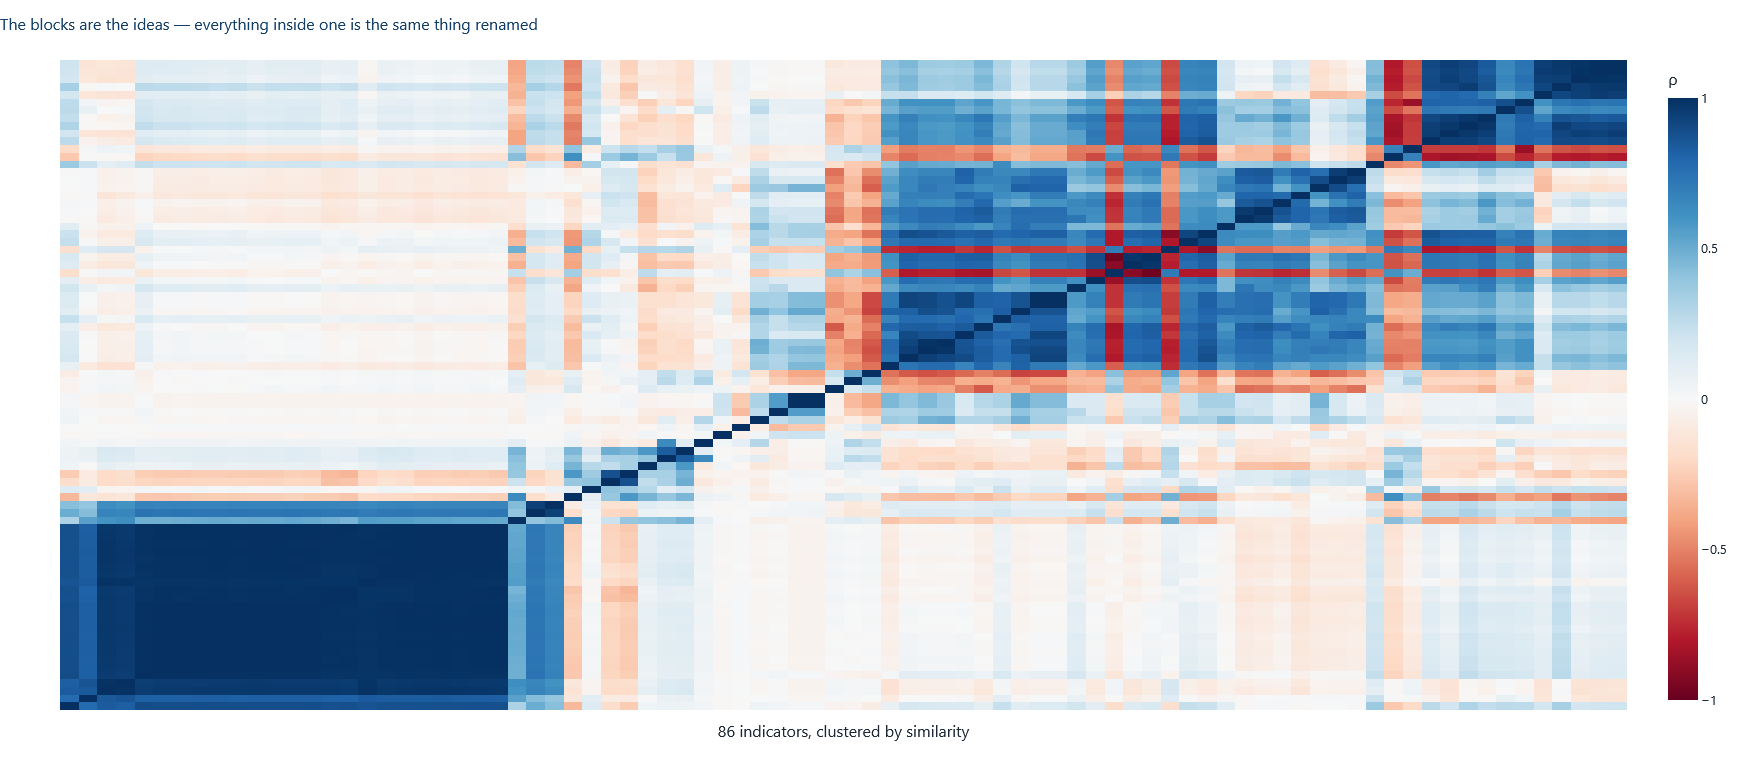

Blocks of near-identical indicators: 14 clusters requested; largest holds 24 features.


In [49]:
link = linkage(1 - corr.abs().values, method="average")
order = dendrogram(link, no_plot=True)["leaves"]
groups = fcluster(link, t=14, criterion="maxclust")
ordered = corr.iloc[order, order]

fig = go.Figure(go.Heatmap(
    z=ordered.values, x=ordered.columns, y=ordered.index,
    colorscale="RdBu", zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title="ρ"),
    hovertemplate="%{y}<br>%{x}<br>ρ = %{z:.2f}<extra></extra>"))
fig.update_xaxes(showticklabels=False, title="86 indicators, clustered by similarity")
fig.update_yaxes(showticklabels=False, title="")
style(fig, height=760, legend_top=False,
      title="The blocks are the ideas — everything inside one is the same thing renamed")
fig.show()

print(f"Blocks of near-identical indicators: {len(set(groups))} clusters requested; "
      f"largest holds {pd.Series(groups).value_counts().iloc[0]} features.")

The block structure is the point. Inside each dark square sit indicators with different names, different inventors and different Investopedia pages, which move together almost perfectly.

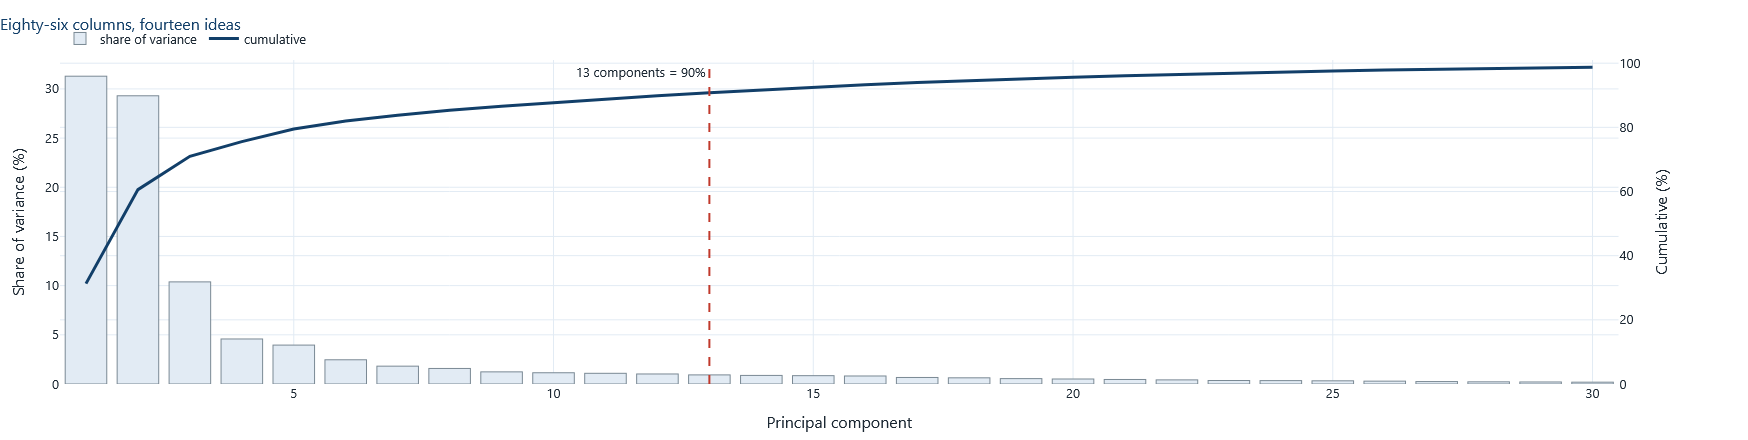

In [50]:
ev = np.linalg.eigvalsh(np.cov(Zc.values.T))[::-1]
ev = ev / ev.sum()
cum = np.cumsum(ev)
n90 = int(np.searchsorted(cum, 0.90) + 1)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=np.arange(1, 31), y=ev[:30] * 100, name="share of variance",
                     marker_color=C["band"], marker_line=dict(color=C["grey"], width=1)))
fig.add_trace(go.Scatter(x=np.arange(1, 31), y=cum[:30] * 100, name="cumulative",
                         line=dict(color=C["navy"], width=3)), secondary_y=True)
fig.add_vline(x=n90, line=dict(color=C["red"], width=2, dash="dash"),
              annotation_text=f"{n90} components = 90%", annotation_position="top left")
fig.update_xaxes(title="Principal component")
fig.update_yaxes(title="Share of variance (%)", secondary_y=False)
fig.update_yaxes(title="Cumulative (%)", secondary_y=True, range=[0, 101])
style(fig, height=440, title="Eighty-six columns, fourteen ideas")
fig.show()

I used the following prompt in Claude:

*Is there a way to build a biplot for PC1 and PC2 where the ta features can be plotted as vectors to see if they cluster? For AAPL stock only. And I want interactive graph, so use Plotly please.*

to get the code below:

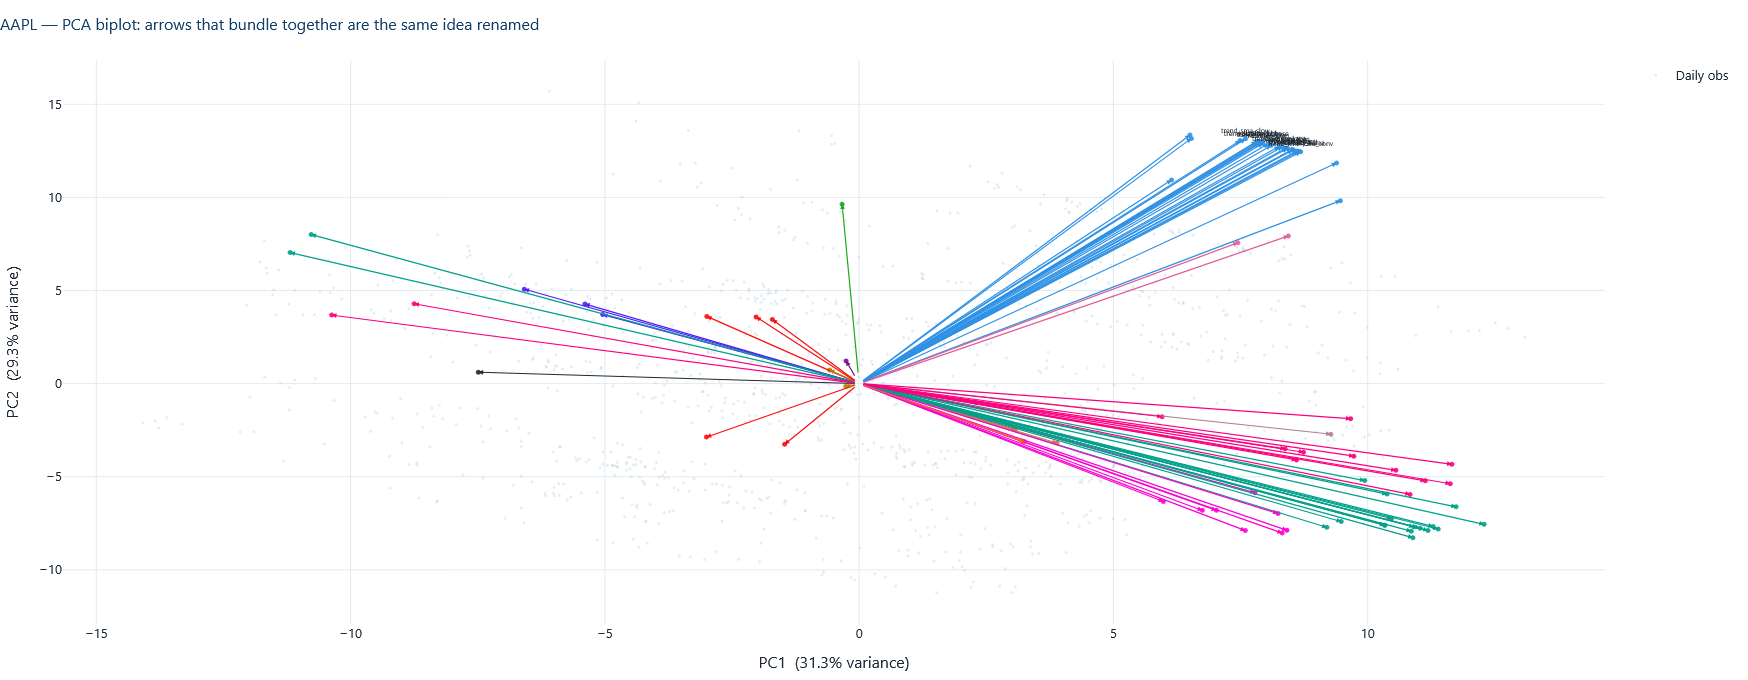

In [51]:
from sklearn.decomposition import PCA
import plotly.express as px

# ── 1. AAPL features ─────────────────────────────────────────────────
o = a.load_ohlcv("AAPL")
F = a.ta_features(o)
F = F.loc[:, F.std() > 0]
Z = (F - F.mean()) / F.std()

# ── 2. Cluster labels (same pipeline as heatmap) ─────────────────────
corr   = Z.corr()
link   = linkage(1 - corr.abs().values, method="average")
groups = fcluster(link, t=14, criterion="maxclust")   # (n_features,)

# ── 3. PCA ───────────────────────────────────────────────────────────
pca      = PCA(n_components=2)
scores   = pca.fit_transform(Z)      # (n_dates, 2)
loadings = pca.components_.T         # (n_features, 2)
ev       = pca.explained_variance_ratio_

# scale vectors to sit comfortably inside the score cloud
scale = np.max(np.abs(scores)) * 0.85 / np.max(np.abs(loadings))
L     = loadings * scale

feat_names = F.columns.tolist()

# label only the top-15 most influential features (largest loading magnitude)
mag     = np.linalg.norm(loadings, axis=1)
top_idx = set(np.argsort(mag)[-15:])

palette = px.colors.qualitative.Dark24
colours = [palette[(g - 1) % len(palette)] for g in groups]

# ── 4. Build figure ──────────────────────────────────────────────────
fig = go.Figure()

# daily observation cloud
fig.add_trace(go.Scatter(
    x=scores[:, 0], y=scores[:, 1],
    mode="markers",
    marker=dict(size=3, color="#aec6cf", opacity=0.3, line=dict(width=0)),
    name="Daily obs",
    hovertemplate="PC1 %{x:.2f}  PC2 %{y:.2f}<extra></extra>",
))

# arrows via add_annotation (gives real arrowheads, one per feature)
for i, (name, col) in enumerate(zip(feat_names, colours)):
    fig.add_annotation(
        x=L[i, 0], y=L[i, 1],
        ax=0, ay=0,
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=2,
        arrowcolor=col, arrowwidth=1.2, arrowsize=0.8,
    )

# invisible scatter at arrow tips — carries hover + cluster labels for top features
fig.add_trace(go.Scatter(
    x=L[:, 0], y=L[:, 1],
    mode="markers+text",
    marker=dict(size=5, color=colours, opacity=0.9),
    text=[name if i in top_idx else "" for i, name in enumerate(feat_names)],
    textposition="top center",
    textfont=dict(size=7),
    customdata=list(zip(feat_names, groups)),
    hovertemplate="<b>%{customdata[0]}</b><br>Cluster %{customdata[1]}<br>"
                  "PC1 load: %{x:.3f}<br>PC2 load: %{y:.3f}<extra></extra>",
    showlegend=False,
))

# origin crosshairs
fig.update_xaxes(title=f"PC1  ({ev[0]:.1%} variance)",
                 zeroline=True, zerolinewidth=1, zerolinecolor="lightgrey")
fig.update_yaxes(title=f"PC2  ({ev[1]:.1%} variance)",
                 zeroline=True, zerolinewidth=1, zerolinecolor="lightgrey")

style(fig, height=680, width=900, legend_top=False,
      title="AAPL — PCA biplot: arrows that bundle together are the same idea renamed")
fig.show()

I then followed up with the following Claude prompt: *Can I now try 3D biplot?* to produce the code below:

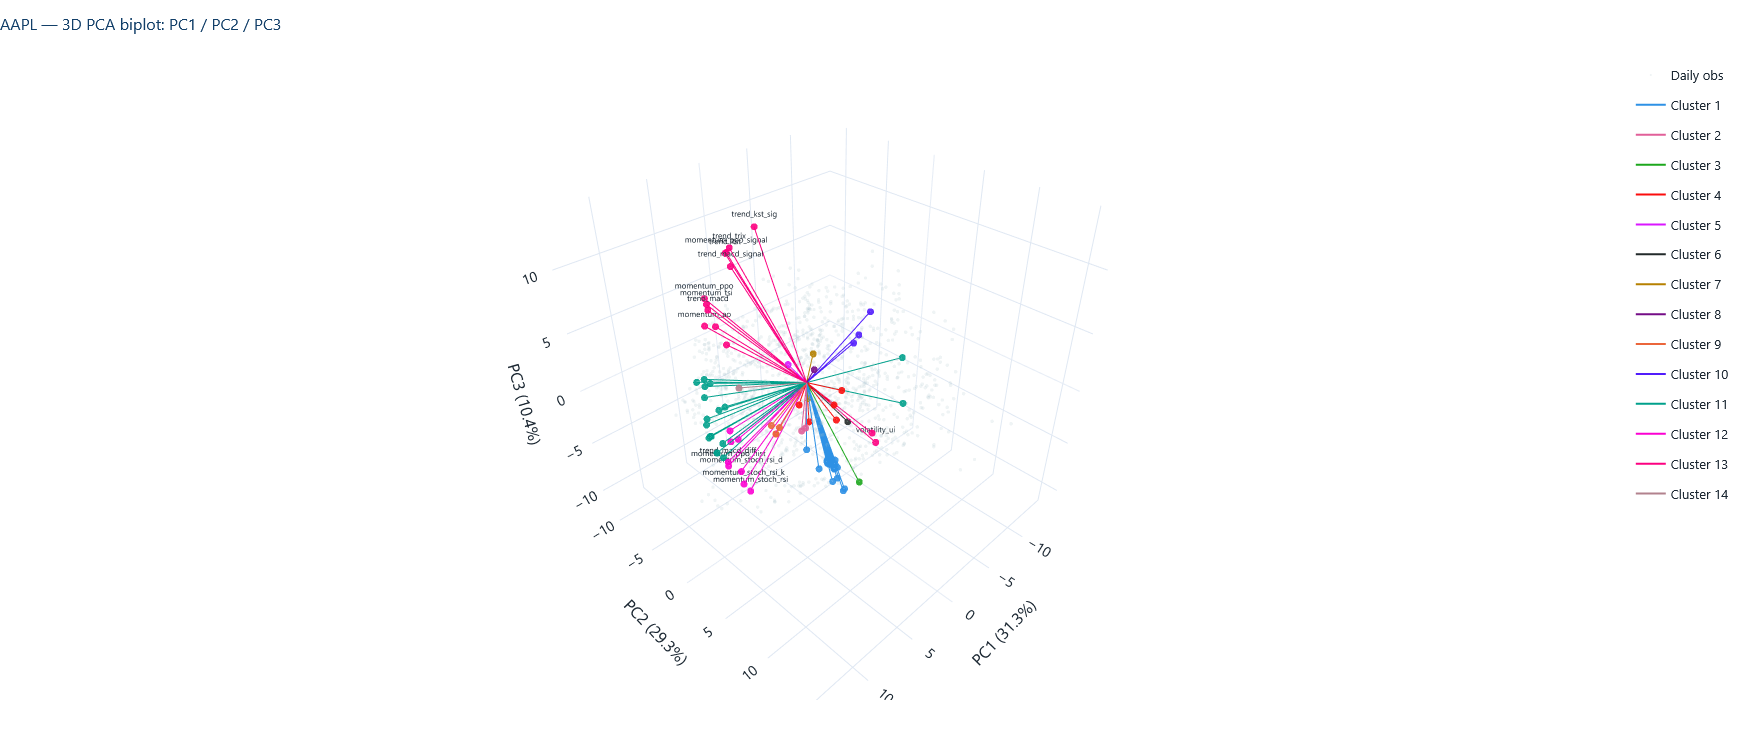

In [52]:
# ── 1. PCA with 3 components ──────────────────────────────────────────
pca      = PCA(n_components=3)
scores   = pca.fit_transform(Z)       # (n_dates, 3)
loadings = pca.components_.T          # (n_features, 3)
ev       = pca.explained_variance_ratio_

scale = np.max(np.abs(scores)) * 0.85 / np.max(np.abs(loadings))
L     = loadings * scale

feat_names = F.columns.tolist()
mag        = np.linalg.norm(loadings, axis=1)
top_idx    = set(np.argsort(mag)[-15:])

palette = px.colors.qualitative.Dark24
colours = [palette[(g - 1) % len(palette)] for g in groups]

# ── 2. Figure ─────────────────────────────────────────────────────────
fig = go.Figure()

# daily observation cloud
fig.add_trace(go.Scatter3d(
    x=scores[:, 0], y=scores[:, 1], z=scores[:, 2],
    mode="markers",
    marker=dict(size=2, color="#aec6cf", opacity=0.2),
    name="Daily obs",
    hovertemplate="PC1 %{x:.2f}<br>PC2 %{y:.2f}<br>PC3 %{z:.2f}<extra></extra>",
))

# loading vectors — one trace per cluster, lines batched with None separators
for g_id in sorted(set(groups)):
    idxs = [i for i, g in enumerate(groups) if g == g_id]
    col  = palette[(g_id - 1) % len(palette)]
    xs, ys, zs = [], [], []
    for i in idxs:
        xs += [0, L[i, 0], None]
        ys += [0, L[i, 1], None]
        zs += [0, L[i, 2], None]
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="lines",
        line=dict(color=col, width=2),
        name=f"Cluster {g_id}",
        legendgroup=f"c{g_id}",
        showlegend=True,
        hoverinfo="skip",
    ))

# markers + labels at arrow tips
fig.add_trace(go.Scatter3d(
    x=L[:, 0], y=L[:, 1], z=L[:, 2],
    mode="markers+text",
    marker=dict(size=4, color=colours, opacity=0.9),
    text=[n if i in top_idx else "" for i, n in enumerate(feat_names)],
    textposition="top center",
    textfont=dict(size=8),
    customdata=list(zip(feat_names, groups)),
    hovertemplate="<b>%{customdata[0]}</b><br>Cluster %{customdata[1]}<br>"
                  "PC1: %{x:.3f}<br>PC2: %{y:.3f}<br>PC3: %{z:.3f}<extra></extra>",
    showlegend=False,
))

# ── 3. Layout ─────────────────────────────────────────────────────────
style(fig, height=750, legend_top=False,
      title="AAPL — 3D PCA biplot: PC1 / PC2 / PC3")

fig.update_layout(scene=dict(
    xaxis_title=f"PC1 ({ev[0]:.1%})",   # same pattern as the corrected answer
    yaxis_title=f"PC2 ({ev[1]:.1%})",
    zaxis_title=f"PC3 ({ev[2]:.1%})",
    aspectmode="cube",
))

fig.show()

**Just in case you are curious:**
Now the cross-check that matters, because a sceptic should ask whether this is a property of markets or a property of one Python package.

**TA-Lib** is a *different library* with a different lineage — a C implementation dating from the early 2000s, with its own conventions and a larger function count. If the redundancy is real, it should reappear there.

In [53]:
if HAS_TALIB:
    from talib import abstract

    inputs = {k: ohlcv[k.capitalize()].values.astype(float)
              for k in ["open", "high", "low", "close", "volume"]}
    groups_wanted = ["Momentum Indicators", "Overlap Studies",
                     "Volatility Indicators", "Volume Indicators"]
    funcs = [f for g in groups_wanted for f in talib.get_function_groups()[g]]

    built = {}
    for fn in funcs:
        try:
            out = abstract.Function(fn)(inputs)
        except Exception:
            continue                       # a few need parameters we have not set
        if isinstance(out, list):          # multi-output, e.g. MACD, BBANDS
            for j, arr in enumerate(out):
                built[f"{fn}_{j}"] = arr
        else:
            built[fn] = out

    T = pd.DataFrame(built, index=ohlcv.index).replace([np.inf, -np.inf], np.nan)
    T = T.loc[:, T.isna().mean() < 0.2].dropna()
    T = T.loc[:, T.std() > 0]
    Zt = (T - T.mean()) / T.std()
    evt = np.linalg.eigvalsh(np.cov(Zt.values.T))[::-1]
    evt = evt / evt.sum()
    nt = int(np.searchsorted(np.cumsum(evt), 0.90) + 1)

    print(f"{'library':<10}{'indicators':>12}{'PCs for 90%':>14}{'compression':>13}{'PC1':>8}")
    print(f"{'TA-Lib':<10}{T.shape[1]:>12}{nt:>14}{nt/T.shape[1]:>12.0%}{evt[0]:>8.1%}")
    print(f"{'ta':<10}{F.shape[1]:>12}{n90:>14}{n90/F.shape[1]:>12.0%}{ev[0]:>8.1%}")
else:
    print("TA-Lib not installed — `pip install TA-Lib` now ships binary wheels, "
          "so no C compiler is required. Skipping the cross-check.")

library     indicators   PCs for 90%  compression     PC1
TA-Lib              69             8         12%   34.5%
ta                  84            13         15%   31.3%


Two independent libraries, built decades apart by different people with different function mixes, and the same verdict: whatever the column count, roughly seven-eighths of it is duplication, and the first principal component — a trend factor — carries about a third of the variance in both. TA-Lib is if anything the more redundant of the two.

The redundancy is a property of price series, not of anyone's code.

**What follows from this.** Feeding all eighty-six columns to a model does not give it more information than feeding it fourteen. It gives it more ways to fit noise, and it makes every feature-importance measure unreadable — because when two features are near-identical, importance is split arbitrarily between them, and each looks weak.

## 3. Every indicator is a hypothesis with free parameters

RSI is conventionally computed over fourteen days. Bollinger bands are conventionally two standard deviations wide. Moving-average crossovers conventionally use fifty and two hundred.

None of these numbers is a fact about markets. Welles Wilder chose fourteen in 1978. Two is a familiar number. Fifty and two hundred are round fractions of a trading year. Each is a free parameter, and each free parameter multiplies the space you are about to search — which, after Lecture 5a, you know is the quantity that decides what your result means.

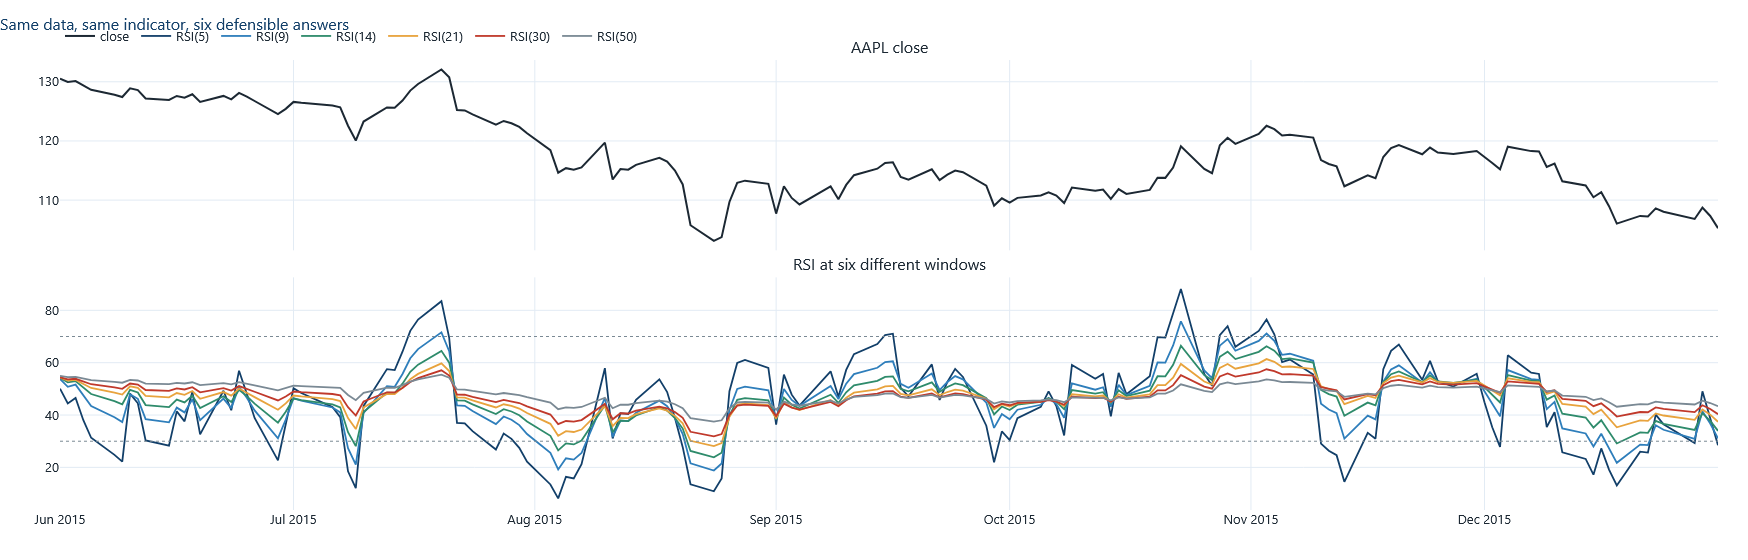

Days flagged oversold over the full five years:

RSI(5)     160
RSI(9)      74
RSI(14)     35
RSI(21)      8
RSI(30)      0
RSI(50)      0


In [54]:
close = ohlcv.Close
windows = [5, 9, 14, 21, 30, 50]
rsis = pd.DataFrame({w: ta.momentum.RSIIndicator(close, window=w).rsi()
                     for w in windows}).dropna()

seg = slice("2015-06-01", "2015-12-31")
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.45, 0.55],
                    vertical_spacing=0.06,
                    subplot_titles=("AAPL close", "RSI at six different windows"))
fig.add_trace(go.Scatter(x=close[seg].index, y=close[seg], name="close",
                         line=dict(color=C["ink"], width=2)), row=1, col=1)
for w, colr in zip(windows, [C["navy"], C["blue"], C["green"], C["amber"],
                             C["red"], C["grey"]]):
    fig.add_trace(go.Scatter(x=rsis[seg].index, y=rsis[seg][w], name=f"RSI({w})",
                             line=dict(color=colr, width=1.8)), row=2, col=1)
fig.add_hline(y=30, line=dict(color=C["grey"], width=1, dash="dot"), row=2, col=1)
fig.add_hline(y=70, line=dict(color=C["grey"], width=1, dash="dot"), row=2, col=1)
style(fig, height=560, title="Same data, same indicator, six defensible answers")
fig.show()

oversold = pd.Series({f"RSI({w})": int((rsis[w] < 30).sum()) for w in windows})
print("Days flagged oversold over the full five years:\n")
print(oversold.to_string())

The shortest window fires an oversold signal many times more often than the longest. These are not disagreements about the data; they are six different questions, each of which someone could describe as "the RSI signal".

Now count. Four indicator families, each with a window and a threshold, is already a four-figure search space before a model has been fitted:

In [55]:
n_fast, n_slow, n_thresholds, n_families = 10, 10, 3, 4
n_rules = n_fast * n_slow * n_thresholds * n_families
print(f"{n_fast} fast × {n_slow} slow × {n_thresholds} thresholds × "
      f"{n_families} families = {n_rules:,} candidate rules")
print(f"\nHurdle at that many trials (using Lec05a's σ = 0.220): "
      f"{a.expected_max_sharpe(n_rules, 0.220):.2f}")
print("Hurdle if you had tried only the three conventional settings: "
      f"{a.expected_max_sharpe(3, 0.220):.2f}")

10 fast × 10 slow × 3 thresholds × 4 families = 1,200 candidate rules

Hurdle at that many trials (using Lec05a's σ = 0.220): 0.73
Hurdle if you had tried only the three conventional settings: 0.19


The conventions are doing something underhanded here. Using RSI(14) *because it is standard* is only honest if you would have reported RSI(14) whatever it showed. If you would have quietly moved to RSI(21) after a poor result, you have searched a grid of ten and must be judged against the higher hurdle — even though you only ran one backtest.

**The number of trials is the number you *would* have run, not the number you did.**

## 4. The stationarity trap

Prices are non-stationary: their mean and variance drift, so a model fitted on one stretch does not transfer to another. The standard fix is to difference them into returns.

But differencing is not free. Returns are stationary and almost memoryless — the level information that made the series worth modelling is gone. A price of $150 after a decade at $30 tells you something; a return of +0.4% does not.

Fractional differentiation sits between the two. Instead of differencing once, difference by a fractional order $d$, keeping as much memory as stationarity permits.

<details>
<summary><b>The maths: differencing by a non-integer order</b></summary>

The backshift operator $B$ satisfies $B X_t = X_{t-1}$. Ordinary differencing is $(1-B)^1$. For real $d$, expand binomially:

$$(1-B)^d = \sum_{k=0}^{\infty}\binom{d}{k}(-B)^k = 1 - dB + \frac{d(d-1)}{2!}B^2 - \cdots$$

giving weights $w_k = -w_{k-1}\dfrac{d-k+1}{k}$ with $w_0 = 1$. For $d=1$ the series terminates after two terms — the familiar $X_t - X_{t-1}$, which is why full differencing forgets everything. For fractional $d$ the weights decay slowly, so the transformed series retains a long memory of past levels. We truncate where $|w_k|$ falls below a threshold.
</details>

In [56]:
log_price = np.log(ohlcv.Close)
ds = np.round(np.arange(0, 1.01, 0.05), 2)

diag = []
series = {}
for d in ds:
    x = a.fracdiff(log_price, d).dropna()
    series[d] = x
    diag.append({"d": d, "ADF": adfuller(x, maxlag=1, regression="c", autolag=None)[0],
                 "corr with level": np.corrcoef(x, log_price.loc[x.index])[0, 1],
                 "obs lost": len(log_price) - len(x)})
diag = pd.DataFrame(diag)

crit = adfuller(log_price.diff().dropna(), maxlag=1, regression="c",
                autolag=None)[4]["5%"]
first_stationary = diag[diag.ADF < crit].iloc[0]
print(diag[diag.d.isin([0, 0.2, 0.3, 0.4, 0.5, 1.0])].to_string(index=False))
print(f"\n5% ADF critical value: {crit:.2f}")
print(f"Smallest d that clears it: {first_stationary.d:.2f}  "
      f"(ADF {first_stationary.ADF:.2f}, correlation with the price level "
      f"{first_stationary['corr with level']:.3f})")

    d     ADF  corr with level  obs lost
0.000  -0.931            1.000         0
0.200  -2.511            0.952       496
0.300  -4.325            0.839       387
0.400  -6.762            0.658       281
0.500  -9.739            0.525       199
1.000 -24.785            0.024         1

5% ADF critical value: -2.86
Smallest d that clears it: 0.25  (ADF -3.38, correlation with the price level 0.906)


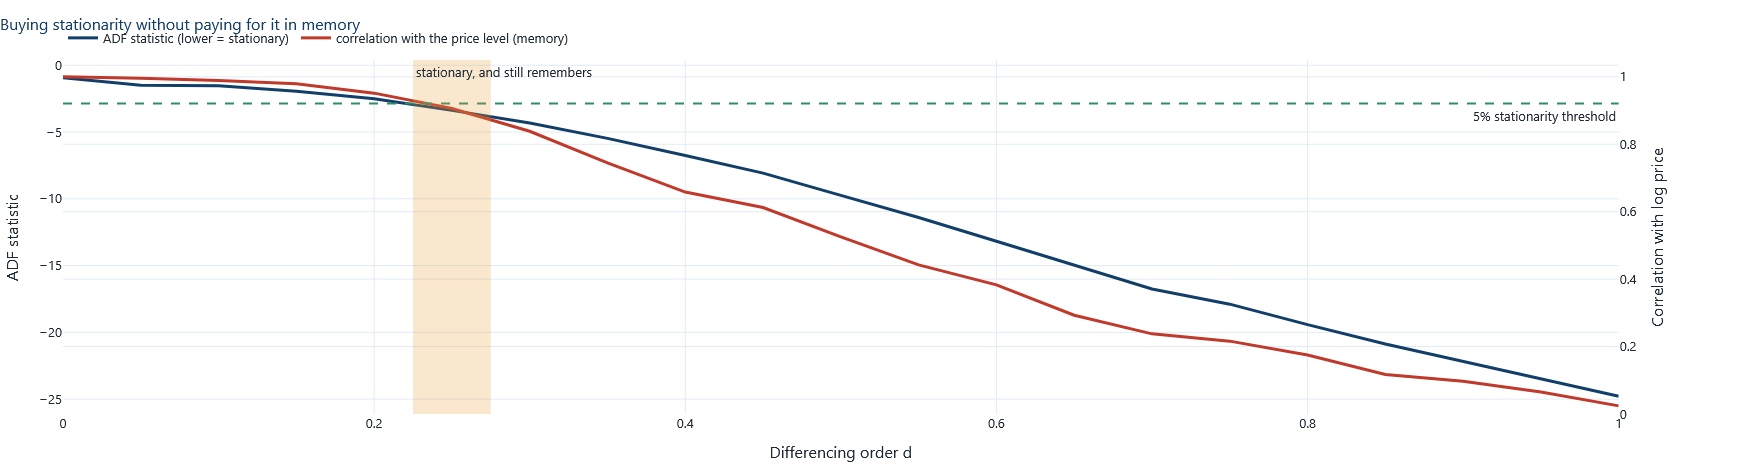

In [57]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=diag.d, y=diag.ADF, name="ADF statistic (lower = stationary)",
                         line=dict(color=C["navy"], width=3)))
fig.add_trace(go.Scatter(x=diag.d, y=diag["corr with level"],
                         name="correlation with the price level (memory)",
                         line=dict(color=C["red"], width=3)), secondary_y=True)
fig.add_hline(y=crit, line=dict(color=C["green"], width=2, dash="dash"),
              annotation_text="5% stationarity threshold", annotation_position="bottom right")
fig.add_vrect(x0=first_stationary.d - 0.025, x1=first_stationary.d + 0.025,
              fillcolor=C["amber"], opacity=0.25, line_width=0,
              annotation_text="stationary, and still remembers", annotation_position="top left")
fig.update_xaxes(title="Differencing order d")
fig.update_yaxes(title="ADF statistic", secondary_y=False)
fig.update_yaxes(title="Correlation with log price", secondary_y=True, range=[0, 1.05])
style(fig, height=470, title="Buying stationarity without paying for it in memory")
fig.show()

The threshold is crossed at $d = 0.25$, where the series is stationary and still carries a correlation of **0.91** with the price level. At the rounder $d = 0.30$ the ADF statistic is −4.33, comfortably past the critical value, with correlation 0.84 still intact.

Full differencing — the thing everyone does by default — takes that correlation to **0.02**.

So the default throws away essentially all of the memory to buy a stationarity that was already available at a quarter of the price. Note also the cost that fractional differencing does charge: small $d$ needs a long weight vector, so you lose observations at the start. At $d = 0.2$ that is nearly 500 rows. Stationarity, memory, sample size — you get to pick two.

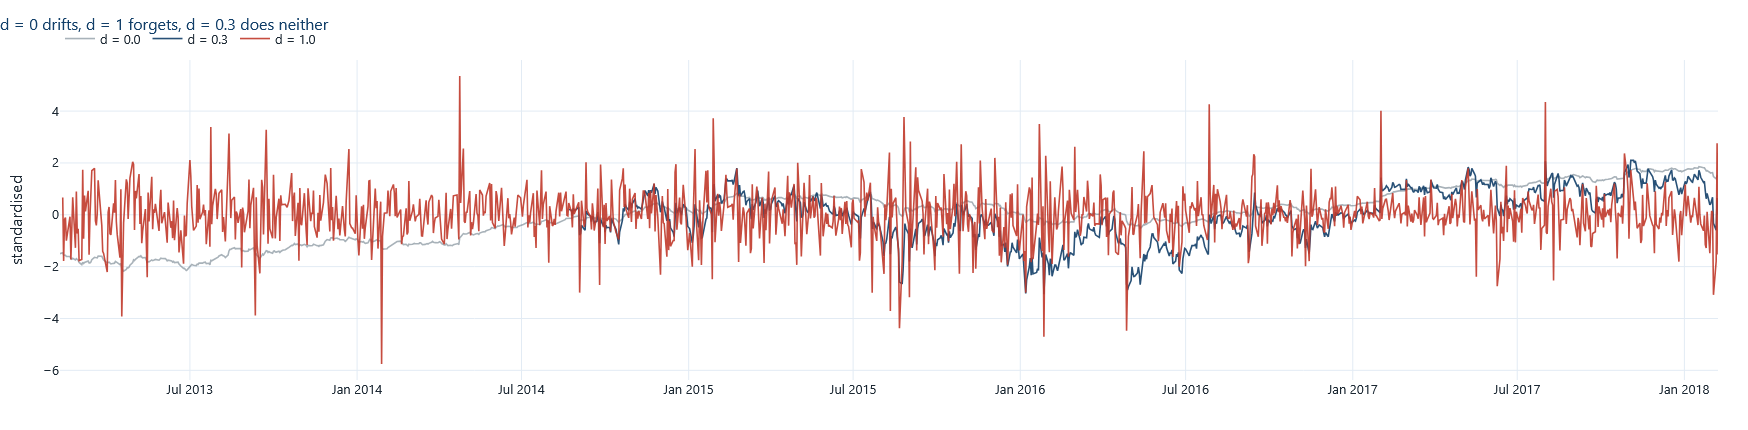

In [58]:
fig = go.Figure()
for d, colr in [(0.0, C["grey"]), (0.3, C["navy"]), (1.0, C["red"])]:
    x = series[d]
    z = (x - x.mean()) / x.std()
    fig.add_trace(go.Scatter(x=z.index, y=z, name=f"d = {d}",
                             line=dict(color=colr, width=1.6),
                             opacity=0.9 if d != 0.0 else 0.65))
fig.update_yaxes(title="standardised")
style(fig, height=430,
      title="d = 0 drifts, d = 1 forgets, d = 0.3 does neither")
fig.show()

## 5. Labels: the choice that decides whether profit was ever possible

Suppose your model predicts direction correctly 52% of the time. Is that good?

The question has no answer until you say what you pay to trade. Win the average move when right, lose it when wrong, pay the cost either way, and break-even accuracy follows immediately.

In [59]:
r_aapl = ohlcv.Close.pct_change().dropna()
E_abs = r_aapl.abs().mean()
print(f"AAPL mean absolute daily move, E|r| = {E_abs:.4%}\n")

costs = np.array([0, 2, 5, 10, 20, 40])
be = pd.DataFrame({"Round-trip cost (bp)": costs,
                   "Accuracy needed": a.break_even_accuracy(costs, E_abs)})
be["Accuracy needed"] = (be["Accuracy needed"] * 100).round(1).astype(str) + " %"
print(be.to_string(index=False))

AAPL mean absolute daily move, E|r| = 1.0401%

 Round-trip cost (bp) Accuracy needed
                    0          50.0 %
                    2          51.0 %
                    5          52.4 %
                   10          54.8 %
                   20          59.6 %
                   40          69.2 %


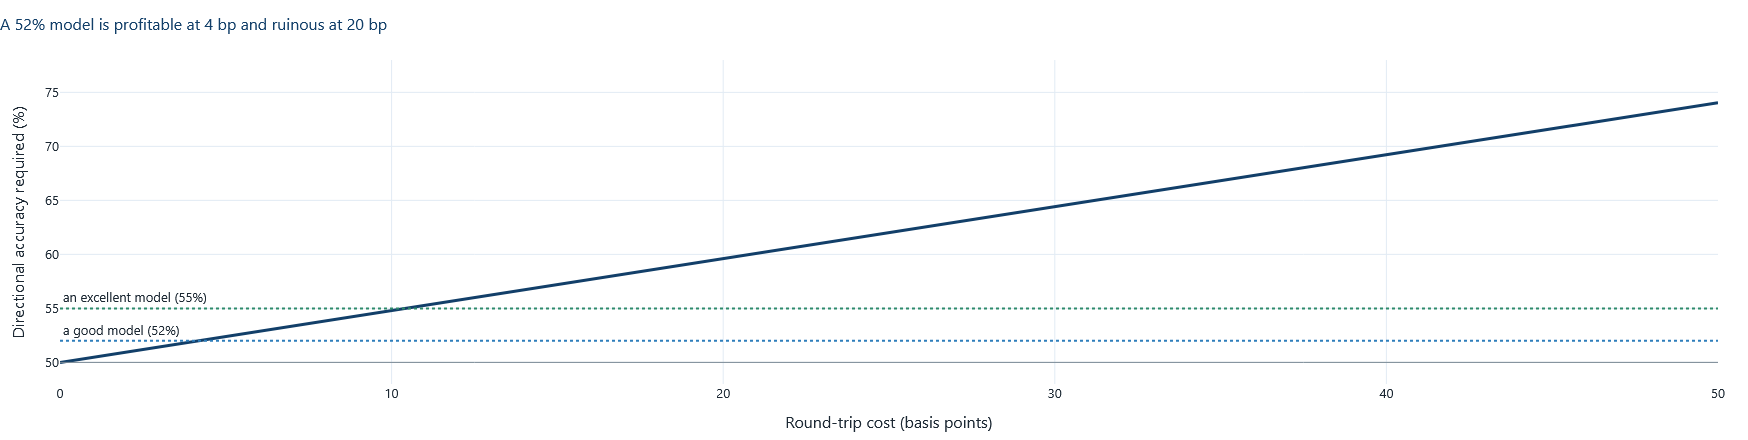

A 52%-accurate daily strategy stops being profitable above 4.3 bp of round-trip cost.


In [60]:
cost_axis = np.linspace(0, 50, 200)
fig = go.Figure()
fig.add_trace(go.Scatter(x=cost_axis, y=a.break_even_accuracy(cost_axis, E_abs) * 100,
                         line=dict(color=C["navy"], width=3), name="break-even accuracy"))
for acc, lab, colr in [(52, "a good model (52%)", C["blue"]),
                       (55, "an excellent model (55%)", C["green"])]:
    fig.add_hline(y=acc, line=dict(color=colr, width=2, dash="dot"),
                  annotation_text=lab, annotation_position="top left")
fig.add_hline(y=50, line=dict(color=C["grey"], width=1))
fig.update_xaxes(title="Round-trip cost (basis points)")
fig.update_yaxes(title="Directional accuracy required (%)", range=[48, 78])
style(fig, height=440,
      title="A 52% model is profitable at 4 bp and ruinous at 20 bp")
fig.show()

kill = cost_axis[a.break_even_accuracy(cost_axis, E_abs) * 100 > 52][0]
print(f"A 52%-accurate daily strategy stops being profitable above "
      f"{kill:.1f} bp of round-trip cost.")

This is why "our model achieves 52% accuracy" is not a result. Accuracy is a property of the model; profitability is a property of the model, the horizon, the average move and the cost — and the last three were fixed before the model was trained.

Note which way the horizon cuts. Lengthen it and $E|r|$ grows roughly with $\sqrt{\text{horizon}}$ while the cost stays fixed, so the accuracy bar falls. Most of the difficulty of high-frequency prediction is not that the signal is weaker; it is that the bar is higher.

## 6. The triple barrier

Fixed-horizon labelling asks: was the return positive ten days later? It is the default, and it has an odd consequence — it forces a verdict on every observation, including the ones where nothing happened.

Triple-barrier labelling asks a better question. Set a profit-taking barrier above, a stop-loss barrier below, and a time limit. The label is whichever one is touched first.

In [61]:
H = 10
fwd = (ohlcv.Close.shift(-H) / ohlcv.Close - 1).dropna()

rows = [{"Labelling": f"Fixed horizon ({H} days)",
         "Up": (fwd > 0).mean(), "Down": (fwd < 0).mean(),
         "No verdict": (fwd == 0).mean()}]
tbs = {}
for k in [0.5, 1.0, 1.5, 2.0, 3.0]:
    tb = a.triple_barrier(ohlcv.Close, horizon=H, upper=k, lower=k)
    tbs[k] = tb
    vc = tb.label.value_counts(normalize=True)
    rows.append({"Labelling": f"Triple barrier, {k:g}σ",
                 "Up": vc.get(1, 0), "Down": vc.get(-1, 0),
                 "No verdict": vc.get(0, 0)})
label_mix = pd.DataFrame(rows)
print(label_mix.to_string(index=False, formatters={
    c: "{:.1%}".format for c in ["Up", "Down", "No verdict"]}))

              Labelling    Up  Down No verdict
Fixed horizon (10 days) 57.2% 42.7%       0.2%
   Triple barrier, 0.5σ 55.4% 44.6%       0.0%
     Triple barrier, 1σ 54.2% 42.3%       3.4%
   Triple barrier, 1.5σ 48.3% 39.9%      11.8%
     Triple barrier, 2σ 43.1% 33.7%      23.3%
     Triple barrier, 3σ 28.9% 21.6%      49.6%


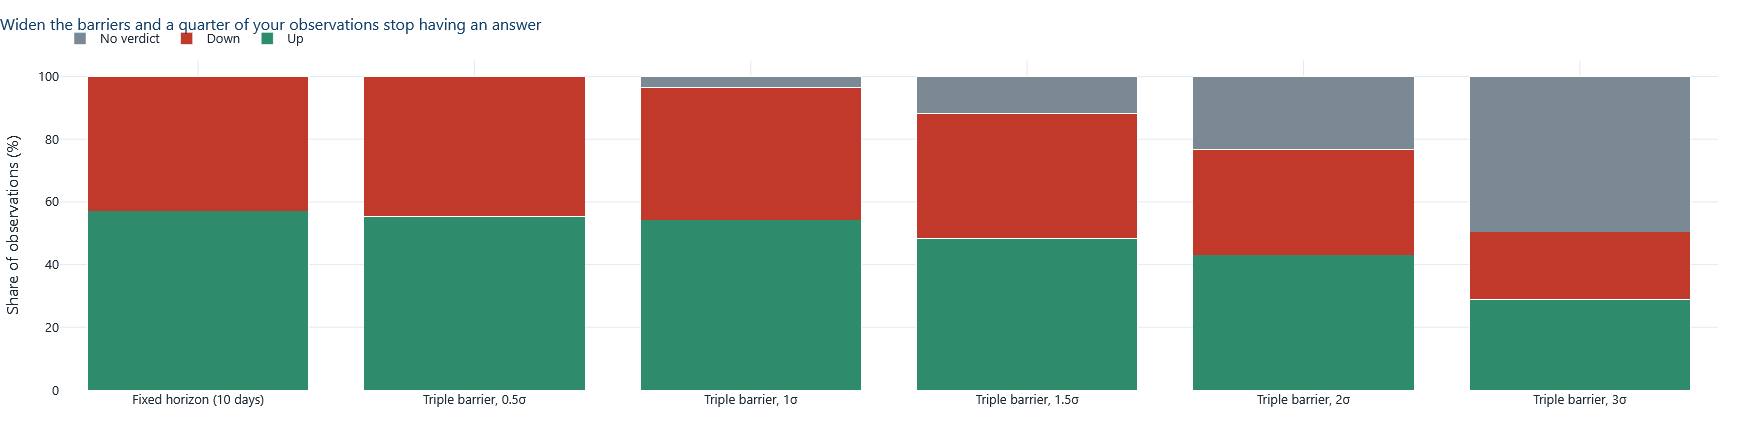

In [62]:
fig = go.Figure()
for col, colr in [("Up", C["green"]), ("Down", C["red"]), ("No verdict", C["grey"])]:
    fig.add_trace(go.Bar(x=label_mix.Labelling, y=label_mix[col] * 100, name=col,
                         marker_color=colr))
fig.update_layout(barmode="stack")
fig.update_yaxes(title="Share of observations (%)")
style(fig, height=440,
      title="Widen the barriers and a quarter of your observations stop having an answer")
fig.show()

At two standard deviations, **23% of observations touch neither barrier** within ten days. Under a fixed-horizon label every one of those was assigned an up or a down, on the strength of whichever side of zero the price happened to land — a coin flip dressed as a class label, and roughly a quarter of your training data.

Here is one event, drawn with its barriers, so the mechanism is visible rather than tabulated.

In [63]:
def draw_event(k=2.0, event_pos=600, horizon=H):
    #tb = tbs.get(k) or a.triple_barrier(ohlcv.Close, horizon=horizon, upper=k, lower=k)
    #tb = tbs[k] if k in tbs else a.triple_barrier(ohlcv.Close, horizon=horizon, upper=k, lower=k)
    tb = tbs.get(k)
    if tb is None:
        tb = a.triple_barrier(ohlcv.Close, horizon=horizon, upper=k, lower=k)
    t0 = tb.index[event_pos]
    i = ohlcv.index.get_loc(t0)
    path = ohlcv.Close.iloc[i: i + horizon + 1]
    p0 = ohlcv.Close.iloc[i]
    vol = ohlcv.Close.pct_change().ewm(span=20).std().iloc[i]
    hi, lo = p0 * (1 + k * vol), p0 * (1 - k * vol)
    row = tb.loc[t0]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=path.index, y=path.values, mode="lines+markers",
                             line=dict(color=C["ink"], width=2.5), name="price"))
    fig.add_hline(y=hi, line=dict(color=C["green"], width=2, dash="dash"),
                  annotation_text=f"profit barrier (+{k:g}σ)", annotation_position="top left")
    fig.add_hline(y=lo, line=dict(color=C["red"], width=2, dash="dash"),
                  annotation_text=f"stop barrier (−{k:g}σ)", annotation_position="top left")
    fig.add_vline(x=path.index[-1], line=dict(color=C["grey"], width=2, dash="dot"),
                  annotation_text="time barrier")
    hit = {1: "profit barrier", -1: "stop barrier", 0: "time barrier"}[row.label]
    style(fig, height=430, legend_top=False,
          title=f"Event {t0.date()} — resolved at the {hit} "
                f"after {int(row.bars_held)} bars, return {row.ret:+.2%}")
    fig.show()

if HAS_WIDGETS:
    W.interact(draw_event,
               k=W.FloatSlider(value=2.0, min=0.5, max=3.0, step=0.5,
                               description="Barrier (σ):"),
               event_pos=W.IntSlider(value=600, min=50, max=1100, step=25,
                                     description="Event:"),
               horizon=W.fixed(H))
else:
    draw_event(k=2.0, event_pos=600)

interactive(children=(FloatSlider(value=2.0, description='Barrier (σ):', max=3.0, min=0.5, step=0.5), IntSlide…

## 7. Meta-labelling

The most genuinely useful thing machine learning does in this pipeline is not predicting direction. It is deciding **whether to act on a signal you already have**.

Split the problem. A primary model — a moving-average crossover, say, or an analyst's recommendation — decides the *side*. A secondary model is then trained on a much easier question: given that the primary model has fired, was it right? Its output governs the *size*, including the size of zero.

The secondary model never has to know which way the market is going. It only has to know when the primary model is unreliable, which is a far lower bar.

In [64]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

X = a.ta_features(ohlcv)
lvl = ohlcv.Close

# Primary model: the crossover from Lec05a. It decides the side, and nothing else.
sig = (lvl.rolling(35).mean() > lvl.rolling(140).mean()).shift(1).reindex(X.index)
fwd5 = (lvl.shift(-5) / lvl - 1).reindex(X.index)

events = sig.fillna(False) & fwd5.notna()
y_meta = (fwd5[events] > 0).astype(int)          # was the primary signal right?
X_meta = X[events]

cut = int(len(X_meta) * 0.6)
Xtr, Xte = X_meta.iloc[:cut], X_meta.iloc[cut:]
ytr, yte = y_meta.iloc[:cut], y_meta.iloc[cut:]

clf = HistGradientBoostingClassifier(max_depth=3, max_iter=200,
                                     learning_rate=0.05, random_state=0)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]

print(f"Events where the primary model was long : {len(X_meta):,}")
print(f"Of those, it was right                  : {y_meta.mean():.1%}\n")

print(f"Base rate in training  : {ytr.mean():.1%}")
print(f"Base rate in testing   : {yte.mean():.1%}   <- it moved; see the note below\n")

# Rank by confidence rather than thresholding the raw probability, because the
# probabilities are calibrated to the training base rate, not the test one.
ret_te = fwd5[events].iloc[cut:]
out = [{"Selection": "take every signal", "Signals taken": f"{len(proba)} (100%)",
        "Hit rate": f"{yte.mean():.1%}",
        "Mean 5-day return": f"{ret_te.mean():+.3%}"}]
# for q in [0.50, 0.25, 0.10]:
#     take = proba >= np.quantile(proba, 1 - q)
#     out.append({"Selection": f"most confident {q:.0%}",
#                 "Signals taken": f"{take.sum()} ({take.mean():.0%})",
#                 "Hit rate": f"{yte[take].mean():.1%}",
#                 "Mean 5-day return": f"{ret_te[take].mean():+.3%}"})
for q in [0.50, 0.25, 0.10]:
    take = proba >= np.quantile(proba, 1 - q)
    hr, n = yte[take].mean(), take.sum()
    out.append({"Selection": f"most confident {q:.0%}",
                "Signals taken": f"{n} ({take.mean():.0%})",
                "Hit rate": f"{hr:.1%}",
                "95% CI": f"±{1.96*np.sqrt(hr*(1-hr)/n)*100:.1f}pp",
                "Mean 5-day return": f"{ret_te[take].mean():+.3%}"})
print(pd.DataFrame(out).to_string(index=False))

Events where the primary model was long : 857
Of those, it was right                  : 57.2%

Base rate in training  : 54.5%
Base rate in testing   : 61.2%   <- it moved; see the note below

         Selection Signals taken Hit rate Mean 5-day return  95% CI
 take every signal    343 (100%)    61.2%           +0.549%     NaN
most confident 50%     172 (50%)    63.4%           +0.550%  ±7.2pp
most confident 25%      86 (25%)    66.3%           +0.684% ±10.0pp
most confident 10%      35 (10%)    60.0%           +0.647% ±16.2pp


Tightening the selection raises the hit rate above the base rate — and the confidence intervals say you cannot conclude that. Every interval in that table overlaps 61.2%. By the top decile you are judging the model on 35 observations, where the interval is wider than the entire effect you are trying to measure.

Whether the ordering comes out monotonic on your machine depends on your scikit-learn version, because with 514 training rows the model's confidence ranking is not stable across releases. If your numbers differ from a classmate's, that is the finding, not a bug. The honest report here is a direction and an error bar, not a ranking. Meta-labelling is a sound idea — the primary model sets the side, the secondary sets the size — but this sample cannot demonstrate it, and saying so is the skill.

Three further things to notice, the last of which is the most important.

The secondary model solves a binary problem with a naturally balanced target and a clear economic meaning, which is why it does better than asking the same algorithm to forecast returns directly.

The base rate moved between training and testing, from 54.5% to 61.2%. The model's predicted probabilities are calibrated to the period it saw, so absolute thresholds like "act when p > 0.6" mean something different out of sample than they did in. Ranking by confidence sidesteps this; calibration would be the fuller answer. Either way, a probability from a model trained on a different regime is not a probability.

And the evaluation above rests on a single train/test split — which, as Lecture 5c will demonstrate at some length, is not a validation at all.

## 8. What to take away

1. **`fillna=True` is not a convenience, it is a decision.** It fabricates values where the parabolic SAR is undefined, backfills a couple of features from the future, and — worst of all — removes the evidence that anything was missing.
2. **Eighty-six indicators contain about fourteen ideas.** Confirmed on five very different stocks and in two independent libraries. Extra columns buy you overfitting and unreadable feature importances.
3. **Every window and threshold is a free parameter**, and the trials you *would* have run count against you as surely as the ones you did.
4. **Full differencing is an over-payment.** At $d = 0.3$ the series is stationary and retains 84% of its correlation with the price level.
5. **The label decides whether profit was ever available.** 52% accuracy is excellent at 4 bp and worthless at 20 bp, and you knew which before you fitted anything.
6. **Fixed-horizon labels force a verdict on observations that have none** — roughly a quarter of them at two-sigma barriers.
7. **Meta-labelling separates the side from the size**, and the size question is the one machine learning is actually good at.

Lecture 5c takes the features and labels built here and asks the only remaining question: how would you know whether any of it works?

## Exercises

**Core**

1. Rebuild the feature matrix with `fillna=True` and train the meta-labelling model on it. Does the test-set hit rate change? Explain why the effect is small here, and construct a situation — a shorter sample, or a different slice — where it would not be.
2. The correlation filter in `airm5.drop_correlated` keeps whichever column comes first. Reverse the column order and re-run it. How many of the surviving features are the same? What does that tell you about reporting "the 48 features we selected"?
3. Repeat the fractional-differentiation analysis on JPM and on NVDA. Is $d = 0.3$ a general answer or an Apple-specific one?
4. Compute break-even accuracy for a 5-day holding period rather than a 1-day one. Explain the direction of the change in one sentence.

**Stretch**

5. The triple barrier here uses symmetric barriers. Make the profit barrier twice the stop barrier and re-run the label mix. Which label becomes rarer, and what does that do to a classifier trained on it?
6. Instead of the correlation filter, use the fourteen principal components as features in the meta-labelling model. Compare test-set performance against the full 86 and against the 48 survivors. Which wins, and does the ranking survive if you change the split date?
7. Overlapping labels break the independence that classifiers assume: a 10-day label at $t$ shares nine days with the label at $t+1$. Implement López de Prado's sample-uniqueness weighting and refit the meta-model with `sample_weight`. Report the change in test-set hit rate.
8. Take the fourteen-component result and test whether it is stable through time: compute the number of components needed for 90% of variance on rolling two-year windows. If the number moves, what does that imply for a model trained on a fixed feature set?